# HOA 7.1

#### vgg16 model from sratch


In [93]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16, MobileNetV2
from tensorflow.keras.utils import plot_model
from tensorflow.keras.layers import Input, Conv2D, BatchNormalization, ReLU, GlobalAveragePooling2D, Dense, DepthwiseConv2D, add
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
from itertools import cycle
import pandas as pd

In [10]:
IMG_SIZE = (224,224)   
BATCH_SIZE = 16 
    

train_ds = tf.keras.utils.image_dataset_from_directory(
    r".\archive\FastAI_ImageNet_v2\train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
).prefetch(tf.data.AUTOTUNE) 

val_ds = tf.keras.utils.image_dataset_from_directory(
    r".\archive\FastAI_ImageNet_v2\val",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
).prefetch(tf.data.AUTOTUNE)



AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

Found 9469 files belonging to 10 classes.
Found 3925 files belonging to 10 classes.


In [3]:
def buildvgg16(input_shape=(224, 224, 3), num_classes=10):
 model = models.Sequential(name="VGG16")


 model.add(layers.Input(shape=input_shape))
 model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='block1_conv1'))
 model.add(layers.Conv2D(64, (3, 3), activation='relu', padding='same', name='block1_conv2'))
 model.add(layers.MaxPooling2D((2, 2), strides=(2, 2), name='block1_pool'))

 model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='block2_conv1'))
 model.add(layers.Conv2D(128, (3, 3), activation='relu', padding='same', name='block2_conv2'))
 model.add(layers.MaxPooling2D((2, 2), strides=(2, 2), name='block2_pool'))

 model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same', name='block3_conv1'))
 model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same', name='block3_conv2'))
 model.add(layers.Conv2D(256, (3, 3), activation='relu', padding='same', name='block3_conv3'))
 model.add(layers.MaxPooling2D((2, 2), strides=(2, 2), name='block3_pool'))

 model.add(layers.Conv2D(512, (3, 3), activation='relu', padding='same', name='block4_conv1'))
 model.add(layers.Conv2D(512, (3, 3), activation='relu', padding='same', name='block4_conv2'))
 model.add(layers.Conv2D(512, (3, 3), activation='relu', padding='same', name='block4_conv3'))
 model.add(layers.MaxPooling2D((2, 2), strides=(2, 2), name='block4_pool'))
 
 
 model.add(layers.Conv2D(512, (3, 3), activation='relu', padding='same', name='block5_conv1'))
 model.add(layers.Conv2D(512, (3, 3), activation='relu', padding='same', name='block5_conv2'))
 model.add(layers.Conv2D(512, (3, 3), activation='relu', padding='same', name='block5_conv3'))
 model.add(layers.MaxPooling2D((2, 2), strides=(2, 2), name='block5_pool'))

 model.add(layers.Flatten(name='flatten'))


 model.add(layers.Dense(4096, activation='relu', name='fc1'))
 model.add(layers.Dropout(0.5, name='drop1'))

 model.add(layers.Dense(4096, activation='relu', name='fc2'))
 model.add(layers.Dropout(0.5, name='drop2'))
 model.add(layers.Dense(num_classes, activation='softmax', name='predictions'))
 return model


![Alt text for the image](conv-layers-vgg16-1024x450.jpg)


i've followed what a certain website looks like about the vgg16 similar to it and few configuration to make sure that my model will run


In [4]:
model = buildvgg16(input_shape=(224, 224, 3), num_classes=10)

In [5]:
model.summary()

Model: "VGG16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 block1_conv1 (Conv2D)       (None, 224, 224, 64)      1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 224, 224, 64)      36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 112, 112, 64)      0         
                                                                 
 block2_conv1 (Conv2D)       (None, 112, 112, 128)     73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 112, 112, 128)     147584    
                                                                 
 block2_pool (MaxPooling2D)  (None, 56, 56, 128)       0         
                                                                 
 block3_conv1 (Conv2D)       (None, 56, 56, 256)       295168

In [ ]:
# ── 1. ACCURACY PLOT ─────────────────────────────────────────────────────────
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'],     label='Train Accuracy',      marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy',  marker='o')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('accuracy_plot.png', dpi=150)
plt.show()

# ── 2. GET TRUE LABELS & PREDICTIONS ─────────────────────────────────────────
y_true, y_pred_probs = [], []

for images, labels in val_ds:
    probs = model.predict(images, verbose=0)
    y_pred_probs.extend(probs)
    y_true.extend(labels.numpy())

y_true       = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)
y_pred       = np.argmax(y_pred_probs, axis=1)

# Class names — replace with your actual class names if known
class_names = [str(i) for i in range(10)]
# e.g. class_names = ['class_0', 'class_1', ..., 'class_9']

# ── 3. CONFUSION MATRIX ──────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# ── 4. CLASSIFICATION REPORT ─────────────────────────────────────────────────
report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
report_df = pd.DataFrame(report).transpose()

# Sensitivity = Recall, so it's already included
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Plot as heatmap
metrics_df = report_df.loc[class_names, ['precision', 'recall', 'f1-score']]
metrics_df.columns = ['Precision', 'Recall / Sensitivity', 'F1-Score']

plt.figure(figsize=(10, 6))
sns.heatmap(metrics_df.astype(float), annot=True, fmt='.2f', cmap='YlGnBu',
            vmin=0, vmax=1)
plt.title('Classification Report — Precision, Recall, F1-Score per Class')
plt.tight_layout()
plt.savefig('classification_report.png', dpi=150)
plt.show()

# ── 5. ROC AUC CURVE (One-vs-Rest for multiclass) ────────────────────────────
y_true_bin = label_binarize(y_true, classes=list(range(10)))

plt.figure(figsize=(10, 7))
colors = plt.cm.tab10(np.linspace(0, 1, 10))

auc_scores = []
for i, color in zip(range(10), colors):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc     = auc(fpr, tpr)
    auc_scores.append(roc_auc)
    plt.plot(fpr, tpr, color=color, lw=1.5,
             label=f'{class_names[i]} (AUC = {roc_auc:.2f})')

# Macro-average AUC
print(f"\nMacro-Average AUC: {np.mean(auc_scores):.4f}")

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC AUC Curve (One-vs-Rest)')
plt.legend(loc='lower right', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_auc.png', dpi=150)
plt.show()

Epoch 1/10


592/592 [==============================] - 157s 245ms/step - loss: 2.0041 - accuracy: 0.2795 - val_loss: 1.7534 - val_accuracy: 0.4201
Epoch 2/10
592/592 [==============================] - 135s 227ms/step - loss: 1.5807 - accuracy: 0.4616 - val_loss: 1.3788 - val_accuracy: 0.5371
Epoch 3/10
592/592 [==============================] - 136s 230ms/step - loss: 1.3384 - accuracy: 0.5486 - val_loss: 1.2327 - val_accuracy: 0.5901
Epoch 4/10
592/592 [==============================] - 134s 227ms/step - loss: 1.1669 - accuracy: 0.6114 - val_loss: 1.1770 - val_accuracy: 0.6227
Epoch 5/10
592/592 [==============================] - 133s 224ms/step - loss: 1.0650 - accuracy: 0.6472 - val_loss: 1.0694 - val_accuracy: 0.6629
Epoch 6/10
592/592 [==============================] - 136s 230ms/step - loss: 0.9391 - accuracy: 0.6966 - val_loss: 1.0506 - val_accuracy: 0.6724
Epoch 7/10
592/592 [==============================] - 134s 227ms/step - loss: 0.8478 - accuracy: 0.7305 - val_loss: 0.9653 - val_accura

# With pre trained model


In [19]:

base = tf.keras.applications.VGG16(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3)
)
base.trainable = False

inputs  = tf.keras.Input(shape=(224, 224, 3))
x       = tf.keras.applications.vgg16.preprocess_input(inputs)
x       = base(x, training=False)
x       = tf.keras.layers.GlobalAveragePooling2D()(x)
x       = tf.keras.layers.Dense(256, activation='relu')(x)
x       = tf.keras.layers.Dropout(0.5)(x)
outputs = tf.keras.layers.Dense(10, activation='softmax')(x)  

model = tf.keras.Model(inputs, outputs)


model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

model.summary()  


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_6 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 tf.__operators__.getitem (S  (None, 224, 224, 3)      0         
 licingOpLambda)                                                 
                                                                 
 tf.nn.bias_add (TFOpLambda)  (None, 224, 224, 3)      0         
                                                                 
 vgg16 (Functional)          (None, 7, 7, 512)         14714688  
                                                                 
 global_average_pooling2d (G  (None, 512)              0         
 lobalAveragePooling2D)                                          
                                                                 
 dense (Dense)               (None, 256)               131328

In [ ]:

# ── 1. ACCURACY PLOT ─────────────────────────────────────────────────────────
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'],     label='Train Accuracy',      marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy',  marker='o')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('accuracy_plot.png', dpi=150)
plt.show()

# ── 2. GET TRUE LABELS & PREDICTIONS ─────────────────────────────────────────
y_true, y_pred_probs = [], []

for images, labels in val_ds:
    probs = model.predict(images, verbose=0)
    y_pred_probs.extend(probs)
    y_true.extend(labels.numpy())

y_true       = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)
y_pred       = np.argmax(y_pred_probs, axis=1)

# Class names — replace with your actual class names if known
class_names = [str(i) for i in range(10)]
# e.g. class_names = ['class_0', 'class_1', ..., 'class_9']

# ── 3. CONFUSION MATRIX ──────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# ── 4. CLASSIFICATION REPORT ─────────────────────────────────────────────────
report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
report_df = pd.DataFrame(report).transpose()

# Sensitivity = Recall, so it's already included
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Plot as heatmap
metrics_df = report_df.loc[class_names, ['precision', 'recall', 'f1-score']]
metrics_df.columns = ['Precision', 'Recall / Sensitivity', 'F1-Score']

plt.figure(figsize=(10, 6))
sns.heatmap(metrics_df.astype(float), annot=True, fmt='.2f', cmap='YlGnBu',
            vmin=0, vmax=1)
plt.title('Classification Report — Precision, Recall, F1-Score per Class')
plt.tight_layout()
plt.savefig('classification_report.png', dpi=150)
plt.show()

# ── 5. ROC AUC CURVE (One-vs-Rest for multiclass) ────────────────────────────
y_true_bin = label_binarize(y_true, classes=list(range(10)))

plt.figure(figsize=(10, 7))
colors = plt.cm.tab10(np.linspace(0, 1, 10))

auc_scores = []
for i, color in zip(range(10), colors):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc     = auc(fpr, tpr)
    auc_scores.append(roc_auc)
    plt.plot(fpr, tpr, color=color, lw=1.5,
             label=f'{class_names[i]} (AUC = {roc_auc:.2f})')

# Macro-average AUC
print(f"\nMacro-Average AUC: {np.mean(auc_scores):.4f}")

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC AUC Curve (One-vs-Rest)')
plt.legend(loc='lower right', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_auc.png', dpi=150)
plt.show()

Epoch 1/10
592/592 [==============================] - 38s 63ms/step - loss: 2.4470 - accuracy: 0.6474 - val_loss: 0.2621 - val_accuracy: 0.9236
Epoch 2/10
592/592 [==============================] - 36s 61ms/step - loss: 0.5300 - accuracy: 0.8716 - val_loss: 0.1888 - val_accuracy: 0.9445
Epoch 3/10
592/592 [==============================] - 36s 61ms/step - loss: 0.3524 - accuracy: 0.9057 - val_loss: 0.1592 - val_accuracy: 0.9521
Epoch 4/10
592/592 [==============================] - 36s 61ms/step - loss: 0.2478 - accuracy: 0.9271 - val_loss: 0.1417 - val_accuracy: 0.9554
Epoch 5/10
592/592 [==============================] - 37s 62ms/step - loss: 0.2032 - accuracy: 0.9371 - val_loss: 0.1309 - val_accuracy: 0.9587
Epoch 6/10
592/592 [==============================] - 36s 60ms/step - loss: 0.1536 - accuracy: 0.9524 - val_loss: 0.1184 - val_accuracy: 0.9620
Epoch 7/10
592/592 [==============================] - 36s 61ms/step - loss: 0.1425 - accuracy: 0.9559 - val_loss: 0.1128 - val_accuracy:

# Supplementary

#### Mobilenetv2

In [3]:
def expansion_block(x,t,filters,block_id):
    prefix = 'block_{}_'.format(block_id)
    total_filters = t*filters
    x = Conv2D(total_filters,1,padding='same',use_bias=False, name =    prefix +'expand')(x)
    x = BatchNormalization(name=prefix +'expand_bn')(x)
    x = ReLU(6,name = prefix +'expand_relu')(x)
    return x
def depthwise_block(x,stride,block_id):
    prefix = 'block_{}_'.format(block_id)
    x = DepthwiseConv2D(3,strides=(stride,stride),padding ='same', use_bias = False, name = prefix + 'depthwise_conv')(x)
    x = BatchNormalization(name=prefix +'dw_bn')(x)
    x = ReLU(6,name = prefix +'dw_relu')(x)
    return x
def projection_block(x,out_channels,block_id):
    prefix = 'block_{}_'.format(block_id)
    x = Conv2D(filters=out_channels,kernel_size = 1,   padding='same',use_bias=False,name= prefix + 'compress')(x)
    x = BatchNormalization(name=prefix +'compress_bn')(x)
    return x

In [4]:
def Bottleneck(x,t,filters, out_channels,stride,block_id):
    y = expansion_block(x,t,filters,block_id)
    y = depthwise_block(y,stride,block_id)
    y = projection_block(y, out_channels,block_id)
    if y.shape[-1]==x.shape[-1]:
       y = add([x,y])
    return y

In [13]:
def MobileNetV2(input_image = (224,224,3), n_classes=1000):
    inputs = Input(input_image) 
    x = Conv2D(32,3,strides=(2,2),padding='same', use_bias=False)(inputs)
    x = BatchNormalization(name='conv1_bn')(x)
    x = ReLU(6, name='conv1_relu')(x)
    # 17 Bottlenecks
    x = depthwise_block(x,stride=1,block_id=1)
    x = projection_block(x, out_channels=16,block_id=1)
    x = Bottleneck(x, t = 6, filters = x.shape[-1], out_channels = 24, stride = 2,block_id = 2)
    x = Bottleneck(x, t = 6, filters = x.shape[-1], out_channels = 24, stride = 1,block_id = 3)
    x = Bottleneck(x, t = 6, filters = x.shape[-1], out_channels = 32, stride = 2,block_id = 4)
    x = Bottleneck(x, t = 6, filters = x.shape[-1], out_channels = 32, stride = 1,block_id = 5)
    x = Bottleneck(x, t = 6, filters = x.shape[-1], out_channels = 32, stride = 1,block_id = 6)
    x = Bottleneck(x, t = 6, filters = x.shape[-1], out_channels = 64, stride = 2,block_id = 7)
    x = Bottleneck(x, t = 6, filters = x.shape[-1], out_channels = 64, stride = 1,block_id = 8)
    x = Bottleneck(x, t = 6, filters = x.shape[-1], out_channels = 64, stride = 1,block_id = 9)
    x = Bottleneck(x, t = 6, filters = x.shape[-1], out_channels = 64, stride = 1,block_id = 10)
    x = Bottleneck(x, t = 6, filters = x.shape[-1], out_channels = 96, stride = 1,block_id = 11)
    x = Bottleneck(x, t = 6, filters = x.shape[-1], out_channels = 96, stride = 1,block_id = 12)
    x = Bottleneck(x, t = 6, filters = x.shape[-1], out_channels = 96, stride = 1,block_id = 13)
    x = Bottleneck(x, t = 6, filters = x.shape[-1], out_channels = 160, stride = 2,block_id = 14)
    x = Bottleneck(x, t = 6, filters = x.shape[-1], out_channels = 160, stride = 1,block_id = 15)
    x = Bottleneck(x, t = 6, filters = x.shape[-1], out_channels = 160, stride = 1,block_id = 16)
    x = Bottleneck(x, t = 6, filters = x.shape[-1], out_channels = 320, stride = 1,block_id = 17)
    x = Conv2D(filters = 1280,kernel_size = 1,padding='same',use_bias=False, name = 'last_conv')(x)
    x = BatchNormalization(name='last_bn')(x)
    x = ReLU(6,name='last_relu')(x)
    x = GlobalAveragePooling2D(name='global_average_pool')(x)
    output = Dense(n_classes,activation='softmax')(x)
    model = Model(inputs, output)
    return model

In [14]:
model = MobileNetV2(input_image=(224,224,3), n_classes=10)

In [15]:
model.summary()

Model: "model_1"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_2 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d_1 (Conv2D)              (None, 112, 112, 32  864         ['input_2[0][0]']                
                                )                                                                 
                                                                                                  
 conv1_bn (BatchNormalization)  (None, 112, 112, 32  128         ['conv2d_1[0][0]']               
                                )                                                           

In [ ]:

# ── 1. ACCURACY PLOT ─────────────────────────────────────────────────────────
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'],     label='Train Accuracy',      marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy',  marker='o')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('accuracy_plot.png', dpi=150)
plt.show()

# ── 2. GET TRUE LABELS & PREDICTIONS ─────────────────────────────────────────
y_true, y_pred_probs = [], []

for images, labels in val_ds:
    probs = model.predict(images, verbose=0)
    y_pred_probs.extend(probs)
    y_true.extend(labels.numpy())

y_true       = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)
y_pred       = np.argmax(y_pred_probs, axis=1)

# Class names — replace with your actual class names if known
class_names = [str(i) for i in range(10)]
# e.g. class_names = ['class_0', 'class_1', ..., 'class_9']

# ── 3. CONFUSION MATRIX ──────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

# ── 4. CLASSIFICATION REPORT ─────────────────────────────────────────────────
report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
report_df = pd.DataFrame(report).transpose()

# Sensitivity = Recall, so it's already included
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# Plot as heatmap
metrics_df = report_df.loc[class_names, ['precision', 'recall', 'f1-score']]
metrics_df.columns = ['Precision', 'Recall / Sensitivity', 'F1-Score']

plt.figure(figsize=(10, 6))
sns.heatmap(metrics_df.astype(float), annot=True, fmt='.2f', cmap='YlGnBu',
            vmin=0, vmax=1)
plt.title('Classification Report — Precision, Recall, F1-Score per Class')
plt.tight_layout()
plt.savefig('classification_report.png', dpi=150)
plt.show()

# ── 5. ROC AUC CURVE (One-vs-Rest for multiclass) ────────────────────────────
y_true_bin = label_binarize(y_true, classes=list(range(10)))

plt.figure(figsize=(10, 7))
colors = plt.cm.tab10(np.linspace(0, 1, 10))

auc_scores = []
for i, color in zip(range(10), colors):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_probs[:, i])
    roc_auc     = auc(fpr, tpr)
    auc_scores.append(roc_auc)
    plt.plot(fpr, tpr, color=color, lw=1.5,
             label=f'{class_names[i]} (AUC = {roc_auc:.2f})')

# Macro-average AUC
print(f"\nMacro-Average AUC: {np.mean(auc_scores):.4f}")

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC AUC Curve (One-vs-Rest)')
plt.legend(loc='lower right', fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_auc.png', dpi=150)
plt.show()

Epoch 1/40
592/592 [==============================] - 39s 60ms/step - loss: 1.5124 - accuracy: 0.4845 - val_loss: 1.5251 - val_accuracy: 0.4820
Epoch 2/40
592/592 [==============================] - 36s 60ms/step - loss: 1.4896 - accuracy: 0.4932 - val_loss: 1.5160 - val_accuracy: 0.4854
Epoch 3/40
592/592 [==============================] - 35s 59ms/step - loss: 1.4533 - accuracy: 0.5105 - val_loss: 1.4834 - val_accuracy: 0.5011
Epoch 4/40
592/592 [==============================] - 33s 55ms/step - loss: 1.4365 - accuracy: 0.5153 - val_loss: 1.4920 - val_accuracy: 0.5032
Epoch 5/40
592/592 [==============================] - 32s 55ms/step - loss: 1.4172 - accuracy: 0.5156 - val_loss: 1.4572 - val_accuracy: 0.5167
Epoch 6/40
592/592 [==============================] - 32s 55ms/step - loss: 1.3761 - accuracy: 0.5354 - val_loss: 1.4418 - val_accuracy: 0.5182
Epoch 7/40
592/592 [==============================] - 32s 55ms/step - loss: 1.3501 - accuracy: 0.5456 - val_loss: 1.4231 - val_accuracy:

# Pre trained MobilenetV2 

In [59]:
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="data_augmentation")

In [62]:

base_model = MobileNetV2(
    weights='imagenet',       
    include_top=False,        
    input_shape=(224, 224, 3) 
)

base_model.trainable = False


model = models.Sequential([
    data_augmentation,
    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(512, activation='relu',kernel_regularizer=tf.keras.regularizers.l2(0.001)),  
    layers.BatchNormalization(),
    layers.Dropout(0.4),                   

    layers.Dense(256, activation='relu',kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.Dropout(0.7),                   

    layers.Dense(10, activation='softmax')
])


In [64]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy', 
    metrics=['accuracy']
)


In [66]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop, checkpoint, reduce_lr]
)

Epoch 1/10


592/592 [==============================] - 76s 118ms/step - loss: 5.0590 - accuracy: 0.1317 - val_loss: 3.2119 - val_accuracy: 0.2701 - lr: 1.0000e-05
Epoch 2/10
592/592 [==============================] - 70s 118ms/step - loss: 4.6036 - accuracy: 0.1794 - val_loss: 3.0046 - val_accuracy: 0.3526 - lr: 1.0000e-05
Epoch 3/10
592/592 [==============================] - 74s 125ms/step - loss: 4.3442 - accuracy: 0.2158 - val_loss: 2.8873 - val_accuracy: 0.3921 - lr: 1.0000e-05
Epoch 4/10
592/592 [==============================] - 75s 126ms/step - loss: 4.1933 - accuracy: 0.2421 - val_loss: 2.8073 - val_accuracy: 0.4280 - lr: 1.0000e-05
Epoch 5/10
592/592 [==============================] - 72s 121ms/step - loss: 4.0438 - accuracy: 0.2655 - val_loss: 2.7516 - val_accuracy: 0.4415 - lr: 1.0000e-05
Epoch 6/10
592/592 [==============================] - 70s 118ms/step - loss: 3.9947 - accuracy: 0.2746 - val_loss: 2.7017 - val_accuracy: 0.4548 - lr: 1.0000e-05
Epoch 7/10
592/592 [===================

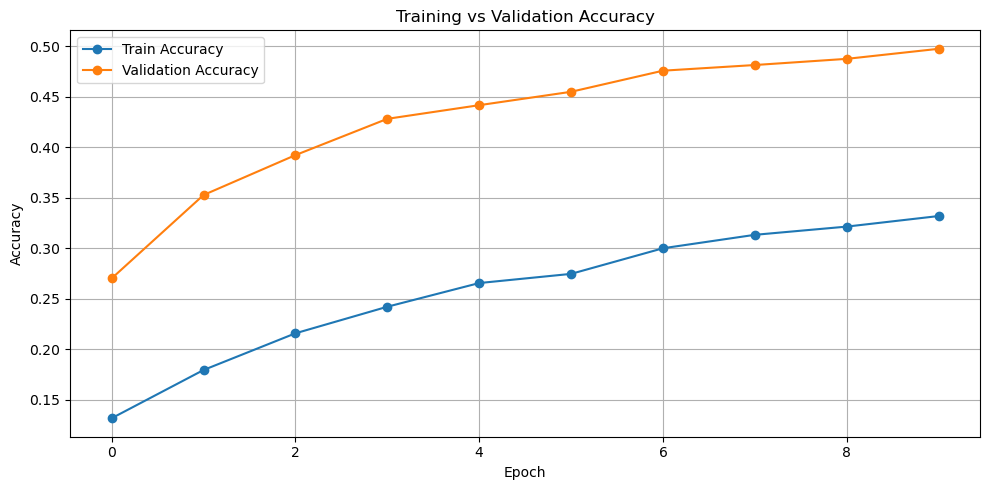

In [67]:
# ── 1. ACCURACY PLOT ─────────────────────────────────────────────────────────
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'],     label='Train Accuracy',      marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy',  marker='o')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
#plt.savefig('accuracy_plot.png', dpi=150)
plt.show()

# with freeze layer

In [68]:
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False


In [69]:

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [70]:
history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[early_stop, checkpoint, reduce_lr]
)

Epoch 1/50


592/592 [==============================] - 73s 116ms/step - loss: 4.4345 - accuracy: 0.2004 - val_loss: 3.2373 - val_accuracy: 0.3913 - lr: 1.0000e-05
Epoch 2/50
592/592 [==============================] - 73s 123ms/step - loss: 4.0199 - accuracy: 0.2593 - val_loss: 2.8214 - val_accuracy: 0.4497 - lr: 1.0000e-05
Epoch 3/50
592/592 [==============================] - 75s 126ms/step - loss: 3.7073 - accuracy: 0.3166 - val_loss: 2.6304 - val_accuracy: 0.4917 - lr: 1.0000e-05
Epoch 4/50
592/592 [==============================] - 69s 117ms/step - loss: 3.5914 - accuracy: 0.3454 - val_loss: 2.5020 - val_accuracy: 0.5322 - lr: 1.0000e-05
Epoch 5/50
592/592 [==============================] - 68s 116ms/step - loss: 3.4596 - accuracy: 0.3743 - val_loss: 2.4309 - val_accuracy: 0.5513 - lr: 1.0000e-05
Epoch 6/50
592/592 [==============================] - 73s 123ms/step - loss: 3.3257 - accuracy: 0.3985 - val_loss: 2.3828 - val_accuracy: 0.5674 - lr: 1.0000e-05
Epoch 7/50
592/592 [===================

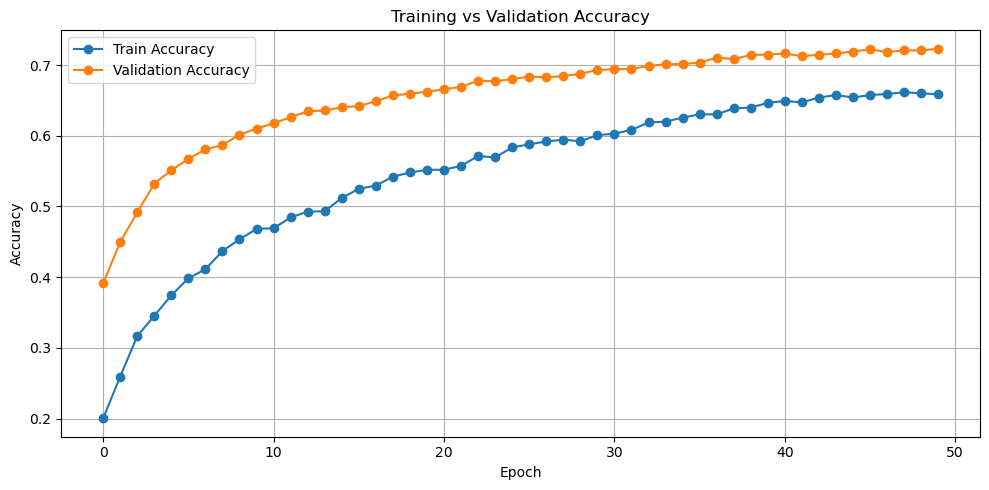

In [73]:
# ── 1. ACCURACY PLOT ─────────────────────────────────────────────────────────
plt.figure(figsize=(10, 5))
plt.plot(history2.history['accuracy'],     label='Train Accuracy',      marker='o')
plt.plot(history2.history['val_accuracy'], label='Validation Accuracy',  marker='o')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
#plt.savefig('accuracy_plot.png', dpi=150)
plt.show()

## History 3

In [89]:
base_model.trainable = True
for layer in base_model.layers[:-15]:
    layer.trainable = False

In [90]:
base_model = MobileNetV2(
    weights='imagenet',       
    include_top=False,        
    input_shape=(224, 224, 3) 
)

base_model.trainable = False


model = models.Sequential([
    data_augmentation,
    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(512, activation='relu',kernel_regularizer=tf.keras.regularizers.l2(0.001)),  
    #layers.BatchNormalization(),
    layers.Dropout(0.4),                   

    layers.Dense(256, activation='relu',kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    #layers.BatchNormalization(),
    layers.Dropout(0.3),                   

    layers.Dense(10, activation='softmax')
])


In [91]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [92]:
history3 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop, checkpoint, reduce_lr]
)

Epoch 1/10


592/592 [==============================] - 76s 119ms/step - loss: 3.4940 - accuracy: 0.1508 - val_loss: 3.0916 - val_accuracy: 0.3205 - lr: 1.0000e-05
Epoch 2/10
 83/592 [===>..........................] - ETA: 52s - loss: 3.2559 - accuracy: 0.2048

KeyboardInterrupt: 

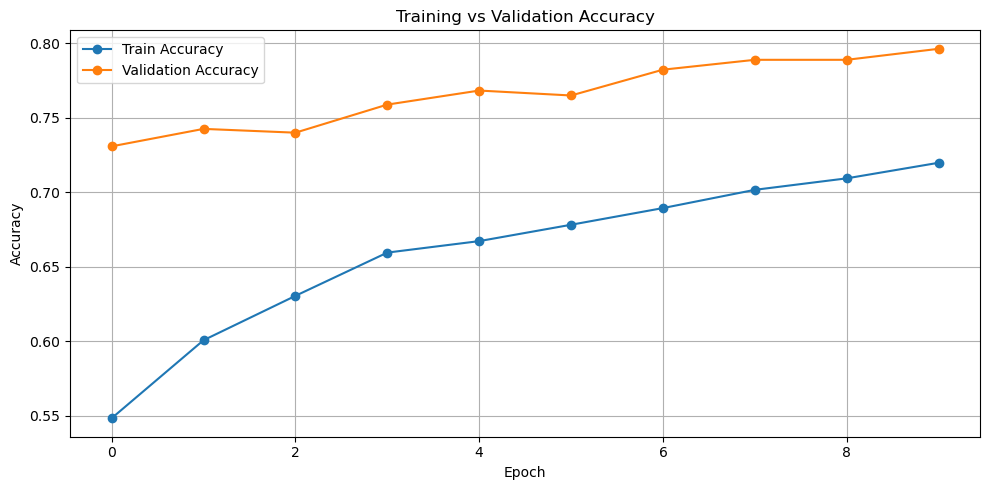

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(history3.history['accuracy'],     label='Train Accuracy',      marker='o')
plt.plot(history3.history['val_accuracy'], label='Validation Accuracy',  marker='o')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
#plt.savefig('accuracy_plot.png', dpi=150)
plt.show()